<a href="https://colab.research.google.com/github/Amzilynn/PIDS-Cowin/blob/main/PI_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Business Understanding

## Problem Statement

The pharmaceutical industry relies heavily on medical delegates as the primary link between pharmaceutical laboratories and healthcare professionals. These delegates are responsible for presenting products, communicating scientific information, addressing objections, and maintaining professional relationships with physicians. The quality of these interactions directly impacts prescribing behavior, regulatory compliance, and overall healthcare outcomes.

Despite their importance, the training and evaluation of medical delegates remain largely subjective and inconsistent. Traditional training methods rely on classroom sessions, scripted role-play, and manual feedback from trainers or managers. These approaches suffer from several limitations:

- Lack of objective evaluation of communication performance
- Limited analysis of non-verbal behavior such as posture, gestures, and facial expressions
- Inconsistent training quality across regions and trainers
- Difficulty in identifying individual skill gaps and learning progression

In addition, pharmaceutical selling is a complex and highly regulated activity. Delegates must adapt their communication style to different healthcare professional profiles while ensuring accurate, compliant, and persuasive product presentation. Existing digital training platforms often focus on content delivery or basic dialogue simulation, without providing comprehensive behavioral assessment or personalized feedback.

Another major challenge concerns product assignment and visit planning. Delegates are often assigned products without a clear data-driven understanding of their communication strengths or therapeutic suitability. Moreover, medical visit scheduling rarely accounts for external factors such as weather conditions, traffic congestion, geographic distance, or doctor availability. This leads to inefficiencies, reduced productivity, and suboptimal engagement strategies.

These challenges highlight the need for an intelligent, integrated system capable of simulating realistic medical visits, objectively evaluating delegate performance, supporting personalized product assignment, and optimizing visit planning decisions.

## Stakeholders Affected

The project directly impacts multiple stakeholders:

- **Medical Delegates**: Require realistic training environments, objective feedback, and personalized guidance to improve communication and confidence.
- **Commercial Delegates**: Need reliable performance indicators to evaluate teams, identify skill gaps, and prioritize coaching actions.
- **Training Directors**: Seek standardized and scalable evaluation methods across regions and therapeutic areas.
- **Human Resources and Talent Development Teams**: Support workforce planning, delegate-product matching, and career development decisions.
- **Pharmaceutical Organization**: Aims to improve training efficiency, sales performance, and return on investment while maintaining regulatory compliance.

## Business Objectives (BO)

Based on the identified challenges, the following business objectives were defined:

- **BO1**: Design and implement an intelligent avatar to train medical delegates through realistic simulations and provide objective feedback on their performance
- **BO2**:Develop a medico-commercial AI assistant capable of presenting pharmaceutical products.
- **BO3**: Personalize product recommendation system that aligns delegate profiles with the most relevant therapeutic products.
- **BO4**: Suggest optimized visit strategies to enhance medical visit planning by incorporating contextual factors such as distance, scheduling constraints, and availability
## Data Science Objectives (DSO)

To support the defined business objectives, the following data science objectives were established:

- **DSO1**:simulate training interactions and evaluate delegate performance
- **DSO2**: Develop models that allow the avatar to present pharmaceutical products accurately.
- **DSO3**:Predict personalized product recommendations based on delegate profiles.
- **DSO4**:Develop predictive models to optimize medical visit planning.

## Summary

In summary, this project addresses a complex business problem involving training quality, behavioral assessment, decision support, and operational efficiency. By integrating artificial intelligence into the delegate training and evaluation process, the solution aims to improve performance consistency, optimize resource allocation, and support data-driven decision-making within Vital.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Import Libraries

This cell imports all the necessary Python libraries for data manipulation, analysis, and visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime

# Data Acquisition and Understanding

### Load Datase dpm_medicaments and Initial Date Parsing

This block loads the medication dataset from a CSV file into a pandas DataFrame and converts the 'Date_AMM' column to a datetime format.

In [ ]:


# Load data
df = pd.read_csv('/content/drive/MyDrive/dpm_medicaments.csv', encoding='utf-8')

# Parse dates (European format: day-month-year)
df['Date_AMM'] = pd.to_datetime(df['Date_AMM'], format='%Y-%m-%d', errors='coerce')

print(f"Loaded {len(df):,} records with {len(df.columns)} columns")
print(f"Columns: {list(df.columns)}")

Loaded 11,693 records with 28 columns
Columns: ['Nom', 'Dosage', 'Forme', 'Présentation', 'DCI', 'Classe', 'Sous_Classe', 'Laboratoire', 'AMM', 'Date_AMM', 'Conditionnement_Primaire', 'Spec_Conditionnement', 'Tableau', 'Duree_Conservation', 'Indications', 'G_P_B', 'VEIC', 'Statut_AMM', 'Lab_Pays', 'Lab_Adresse', 'Lab_Tel', 'Lab_Fax', 'DCI_Link', 'Fiche_Link', 'RCP_PDF', 'Notice_PDF', 'Source_Excel', 'Source_Page']


### Overview of Dataset: Statistics and Missing Values

This cell provides a high-level summary of the dataset, including total records, duplicates, unique entries, and the percentage of missing values for each column.

In [ ]:
df.head()

,Nom,Dosage,Forme,Présentation,DCI,Classe,Sous_Classe,Laboratoire,AMM,Date_AMM,...,Lab_Pays,Lab_Adresse,Lab_Tel,Lab_Fax,DCI_Link,Fiche_Link,RCP_PDF,Notice_PDF,Source_Excel,Source_Page
0,5-FLUOROURACIL,250 MG,Solution injectable,B/5/5ML,FLUOROURACILE,ANTINEOPLASIQUES ET IMMUNOMODULATEURS,ANTINEOPLASIQUES,EBEWE Pharma,6943091H,2001-01-20,...,AUTRICHE,A-4866 UNTERACH AUTRICHE,4376658123,NaN,NaN,NaN,NaN,NaN,https://dpm.tn/images/pdf/liste_amm.xls,https://dpm.tn/medicament/humain/liste-des-med...
1,5-FLUOROURACILE EBEWE,1000 mg/20 ml,Solution injectable pour perfusion,B/1/20 ml,FLUOROURACILE,ANTINEOPLASIQUES ET IMMUNOMODULATEURS,ANTINEOPLASIQUES,EBEWE Pharma,6943093H,2012-04-30,...,AUTRICHE,A-4866 UNTERACH AUTRICHE,4376658123,NaN,NaN,https://dpm.tn/dpm_pharm/medicament/fiche.php?...,NaN,NaN,https://dpm.tn/images/pdf/liste_amm.xls,https://dpm.tn/medicament/humain/liste-des-med...
2,5-FLUOROURACILE EBEWE,500 mg/10 ml,Solution injectable pour perfusion,B/5/10 ml,FLUOROURACILE,ANTINEOPLASIQUES ET IMMUNOMODULATEURS,ANTINEOPLASIQUES,EBEWE Pharma,6943092H,2012-04-30,...,AUTRICHE,A-4866 UNTERACH AUTRICHE,4376658123,NaN,NaN,https://dpm.tn/dpm_pharm/medicament/fiche.php?...,NaN,NaN,https://dpm.tn/images/pdf/liste_amm.xls,https://dpm.tn/medicament/humain/liste-des-med...
3,ABBOTICINE,200 MG,Poudre pour suspension orale,FL/60ML,ERYTHROMYCINE,ANTIINFECTIEUX GENERAUX A USAGE SYSTEMIQUE,ANTIBACTERIENS (USAGE SYSTEMIQUE),ADWYA,9043061,1990-12-19,...,Tunisie,Route de la MARSA KM 14 BP 658 2070 LA MARSA T...,71 854888 71854058 /,NaN,NaN,https://dpm.tn/dpm_pharm/medicament/fiche.php?...,NaN,NaN,https://dpm.tn/images/pdf/liste_amm.xls,https://dpm.tn/medicament/humain/liste-des-med...
4,ABEVMY,400 mg(25mg/ml),Solution à diluer pour perfusion,B/1FL/16ml,BEVACIZUMAB,ANTINEOPLASIQUES ET IMMUNOMODULATEURS,ANTINEOPLASIQUES,MYLAN PHARMACEUTICALS PRIVATE LIMITED,20343022H,2021-09-06,...,Inde,"Plot N°1-A/2, MIDC Industrial Esatate Taloja, ...",NaN,NaN,NaN,NaN,NaN,NaN,https://dpm.tn/images/pdf/liste_amm.xls,https://dpm.tn/medicament/humain/liste-des-med...


In [ ]:
df.shape

(11693, 28)

In [ ]:
df.isnull().sum()
# Missing values
print("\n--- Missing Values (%) ---")
missing = (df.isnull().sum() / len(df) * 100).round(1)
print(missing[missing > 0].sort_values(ascending=False))


--- Missing Values (%) ---
DCI_Link                    100.0
Notice_PDF                   91.0
RCP_PDF                      82.5
Lab_Fax                      74.8
Lab_Tel                      68.0
Lab_Adresse                  49.4
Spec_Conditionnement         49.3
VEIC                         48.7
Indications                  48.3
Classe                       48.2
Sous_Classe                  48.2
Source_Excel                 48.2
Duree_Conservation           48.2
Conditionnement_Primaire     48.2
Tableau                      48.2
Dosage                       10.9
Fiche_Link                    2.8
Lab_Pays                      1.2
Présentation                  0.1
dtype: float64


**The output above shows the number of missing values for each column in your dataset. For example, DCI_Link has 11,693 missing values, while Nom, Forme, AMM, Date_AMM, G_P_B, Statut_AMM, and Source_Page have no missing values.**

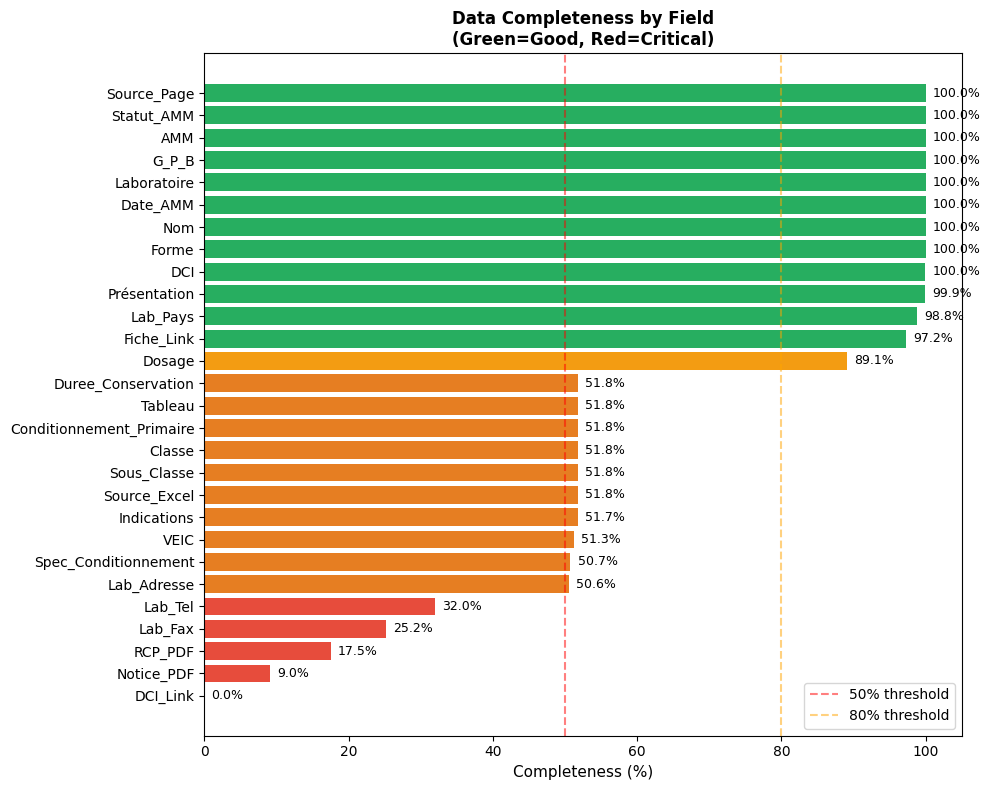

✓ Visualization saved: data_completeness.png

🚨 CRITICAL FIELDS (< 50% complete):
   • DCI_Link: 0.0%
   • Notice_PDF: 9.0%
   • RCP_PDF: 17.5%
   • Lab_Fax: 25.2%
   • Lab_Tel: 32.0%


In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 8)) # Adjusted figsize for a single plot

# Calculate completeness percentage
completeness = (1 - df.isnull().sum() / len(df)) * 100
completeness = completeness.sort_values()

# Color code by severity
colors = []
for val in completeness.values:
    if val >= 95:
        colors.append('#27ae60')  # Green: excellent
    elif val >= 80:
        colors.append('#f39c12')  # Orange: acceptable
    elif val >= 50:
        colors.append('#e67e22')  # Dark orange: concerning
    else:
        colors.append('#e74c3c')  # Red: critical

bars = ax1.barh(range(len(completeness)), completeness.values, color=colors)
ax1.set_yticks(range(len(completeness)))
ax1.set_yticklabels(completeness.index, fontsize=10)
ax1.set_xlabel('Completeness (%)', fontsize=11)
ax1.set_title('Data Completeness by Field\n(Green=Good, Red=Critical)',
              fontsize=12, fontweight='bold')

# Add percentage labels
for i, (bar, val) in enumerate(zip(bars, completeness.values)):
    ax1.text(val + 1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)

# Reference lines
ax1.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax1.axvline(x=80, color='orange', linestyle='--', alpha=0.5, label='80% threshold')
ax1.legend(loc='lower right')

plt.tight_layout() # Ensure labels and title fit
plt.savefig('data_completeness.png') # Save the figure
plt.show() # Display the plot

print("✓ Visualization saved: data_completeness.png")

# Print critical findings
critical_missing = completeness[completeness < 50]
if len(critical_missing) > 0:
    print(f"\n🚨 CRITICAL FIELDS (< 50% complete):")
    for field, pct in critical_missing.items():
        print(f"   • {field}: {pct:.1f}%")

In [ ]:
df.duplicated().sum()

np.int64(6)

In [ ]:
print('Data Types of all columns:')
df.info()

Data Types of all columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11693 entries, 0 to 11692
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Nom                       11693 non-null  object        
 1   Dosage                    10422 non-null  object        
 2   Forme                     11693 non-null  object        
 3   Présentation              11681 non-null  object        
 4   DCI                       11691 non-null  object        
 5   Classe                    6059 non-null   object        
 6   Sous_Classe               6059 non-null   object        
 7   Laboratoire               11693 non-null  object        
 8   AMM                       11693 non-null  object        
 9   Date_AMM                  11693 non-null  datetime64[ns]
 10  Conditionnement_Primaire  6059 non-null   object        
 11  Spec_Conditionnement      5934 non-null   object     

In [ ]:
print('\nDescriptive statistics for numerical columns:')
display(df.describe())


Descriptive statistics for numerical columns:


,Date_AMM,Duree_Conservation,DCI_Link
count,11693,6059.000000,0.0
mean,2003-05-01 18:31:40.829556224,30.930186,NaN
min,1960-01-01 00:00:00,0.000000,NaN
25%,1994-06-16 00:00:00,24.000000,NaN
50%,2003-07-24 00:00:00,24.000000,NaN
75%,2014-05-16 00:00:00,36.000000,NaN
max,2024-04-22 00:00:00,60.000000,NaN
std,NaN,9.261288,NaN


In [ ]:

print("=" * 60)
print("TEXT CLEANING")
print("=" * 60)

# Work on a copy to preserve original
df_clean = df.copy()

# Before/after comparison
print("\nBEFORE cleaning (sample):")
print(f"  DCI: '{df_clean['DCI'].iloc[0]}'" )
print(f"  Lab: '{df_clean['Laboratoire'].iloc[0]}'" )

# Clean medication names: strip whitespace, title case
# Title case: "5-FLUOROURACILE" → "5-Fluorouracile" (better readability)
df_clean['Nom'] = df_clean['Nom'].str.strip().str.title()

# Clean active ingredients: uppercase for standardization
# DCI (Denominazione Comune Internazionale) should be uppercase
df_clean['DCI'] = df_clean['DCI'].str.strip().str.upper()

# Clean laboratory names: title case
df_clean['Laboratoire'] = df_clean['Laboratoire'].str.strip().str.title()

# Clean country names
df_clean['Lab_Pays'] = df_clean['Lab_Pays'].str.strip().str.title()

# Clean therapeutic classifications
df_clean['Classe'] = df_clean['Classe'].str.strip()
df_clean['Sous_Classe'] = df_clean['Sous_Classe'].str.strip()

print("\nAFTER cleaning (same records):")
print(f"  DCI: '{df_clean['DCI'].iloc[0]}'" )
print(f"  Lab: '{df_clean['Laboratoire'].iloc[0]}'" )

# Check for improvement
unique_dci_before = df['DCI'].nunique()
unique_dci_after = df_clean['DCI'].nunique()
print(f"\n✓ DCI uniqueness: {unique_dci_before} → {unique_dci_after} "
      f"(reduced by {unique_dci_before - unique_dci_after} duplicates from spacing)")

TEXT CLEANING

BEFORE cleaning (sample):
  DCI: 'FLUOROURACILE'
  Lab: 'EBEWE Pharma'

AFTER cleaning (same records):
  DCI: 'FLUOROURACILE'
  Lab: 'Ebewe Pharma'

✓ DCI uniqueness: 1907 → 1906 (reduced by 1 duplicates from spacing)


**Strip whitespace, standardize case for text fields**

In [ ]:
import re
import numpy as np

print("=" * 60)
print("REFINED DOSAGE PARSING (MEDICALLY SAFE)")
print("=" * 60)

# Reset dosage columns
df_clean['dosage_value'] = np.nan
df_clean['dosage_unit'] = np.nan
df_clean['dosage_unit_original'] = np.nan
df_clean['dosage_secondary_value'] = np.nan
df_clean['dosage_secondary_unit'] = np.nan
df_clean['dosage_IU_equivalent'] = np.nan  # Only for IU/MU/MUI

# Regex to capture primary and optional secondary dosages
dosage_pattern = r'(\d+[.,]?\d*)\s*(MG|G|ML|UI|IU|MCG|MICROG|UG|UNIT|UNITS|U|MU|MUI|IR|IC|%)' \
                 r'(?:\s*/\s*(\d+[.,]?\d*)\s*(MG|G|ML))?'

parsed_count = 0

for idx in df_clean.index:
    dosage_str = str(df_clean.loc[idx, 'Dosage'])

    if dosage_str == 'nan' or dosage_str.strip() == '':
        continue

    # Standardize string
    dosage_str = dosage_str.upper().replace(',', '.').replace('µG', 'MCG').replace('µ', 'MCG')

    match = re.search(dosage_pattern, dosage_str)

    if match:
        # Primary component
        value_str = match.group(1)
        value = float(value_str)
        unit = match.group(2).strip()
        df_clean.loc[idx, 'dosage_value'] = value
        df_clean.loc[idx, 'dosage_unit'] = unit
        df_clean.loc[idx, 'dosage_unit_original'] = unit  # Keep original

        # Secondary component (if exists)
        if match.group(3) and match.group(4):
            sec_value = float(match.group(3))
            sec_unit = match.group(4).strip()
            df_clean.loc[idx, 'dosage_secondary_value'] = sec_value
            df_clean.loc[idx, 'dosage_secondary_unit'] = sec_unit

        # Handle IU/MU/MUI conversion numerically (not mg!)
        iu_equiv = np.nan
        if unit in ['MU', 'MUI']:
            iu_equiv = value * 1_000_000
        elif unit in ['U', 'UNIT', 'UNITS']:
            iu_equiv = value
        df_clean.loc[idx, 'dosage_IU_equivalent'] = iu_equiv

        parsed_count += 1

# Results
total_records = len(df_clean)
print(f"✓ Successfully parsed: {parsed_count:,} records ({parsed_count/total_records*100:.1f}%)")
print(f"✗ Could not parse: {total_records - parsed_count:,} records")

# Show examples of IU/MU/µG or combination dosages
newly_parsed_examples = df_clean[
    df_clean['dosage_value'].notna() &
    df_clean['Dosage'].str.contains('µG|MU|U/ML|/', na=False, regex=True)
][[
    'Nom', 'Dosage', 'dosage_value', 'dosage_unit',
    'dosage_secondary_value', 'dosage_secondary_unit', 'dosage_IU_equivalent'
]].drop_duplicates().head(10)

print("\n\nEXAMPLES OF NEWLY PARSED DOSAGES:")
print(newly_parsed_examples.to_string())

# Remaining unparsed records
unparsed_dosages_after_refinement = df_clean[df_clean['dosage_value'].isnull()].copy()

REFINED DOSAGE PARSING (MEDICALLY SAFE)


/tmp/ipython-input-376266810.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'MG' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_clean.loc[idx, 'dosage_unit'] = unit
/tmp/ipython-input-376266810.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'MG' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_clean.loc[idx, 'dosage_unit_original'] = unit  # Keep original
/tmp/ipython-input-376266810.py:47: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'ML' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_clean.loc[idx, 'dosage_secondary_unit'] = sec_unit


✓ Successfully parsed: 10,134 records (86.7%)
✗ Could not parse: 1,559 records


EXAMPLES OF NEWLY PARSED DOSAGES:
                                         Nom           Dosage  dosage_value dosage_unit  dosage_secondary_value dosage_secondary_unit  dosage_IU_equivalent
1                      5-Fluorouracile Ebewe    1000 mg/20 ml        1000.0          MG                    20.0                    ML                   NaN
2                      5-Fluorouracile Ebewe     500 mg/10 ml         500.0          MG                    10.0                    ML                   NaN
4                                     Abevmy  400 mg(25mg/ml)         400.0          MG                     NaN                   NaN                   NaN
5                                     Abevmy  100 mg(25mg/ml)         100.0          MG                     NaN                   NaN                   NaN
14                            Acamantine 625     500 mg/125mg         500.0          MG                  

**The next step is to handle critical missing rows by dropping entries with missing 'Nom', 'DCI', or 'Laboratoire', and create boolean flags for missing 'Classe' and 'Indications' as per the subtask instructions. This ensures foundational data integrity before further cleaning.**



In [ ]:
print("\n--- HANDLING CRITICAL MISSING ROWS & FLAGGING ---")

# Before dropping
initial_rows = len(df_clean)
print(f"Initial number of rows: {initial_rows:,}")

# 1. Drop rows where 'Nom', 'DCI', or 'Laboratoire' are missing
critical_columns_to_check = ['Nom', 'DCI', 'Laboratoire']
df_clean.dropna(subset=critical_columns_to_check, inplace=True)

rows_after_dropping = len(df_clean)
print(f"Rows after dropping critical missing values: {rows_after_dropping:,} (Dropped {initial_rows - rows_after_dropping:,} rows)")

# 2. Create boolean flags for missing 'Classe' and 'Indications'
df_clean['missing_Classe'] = df_clean['Classe'].isnull()
df_clean['missing_Indications'] = df_clean['Indications'].isnull()

print("\n✓ Created boolean flags for missing 'Classe' and 'Indications'.")
print(df_clean[['Nom', 'DCI', 'Laboratoire', 'missing_Classe', 'missing_Indications']].head())


--- HANDLING CRITICAL MISSING ROWS & FLAGGING ---
Initial number of rows: 11,693
Rows after dropping critical missing values: 11,691 (Dropped 2 rows)

✓ Created boolean flags for missing 'Classe' and 'Indications'.
                     Nom            DCI  \
0         5-Fluorouracil  FLUOROURACILE   
1  5-Fluorouracile Ebewe  FLUOROURACILE   
2  5-Fluorouracile Ebewe  FLUOROURACILE   
3             Abboticine  ERYTHROMYCINE   
4                 Abevmy    BEVACIZUMAB   

                             Laboratoire  missing_Classe  missing_Indications  
0                           Ebewe Pharma           False                False  
1                           Ebewe Pharma           False                False  
2                           Ebewe Pharma           False                False  
3                                  Adwya           False                False  
4  Mylan Pharmaceuticals Private Limited           False                False  


**Drop columns that have a high percentage of missing values (more than 80-90%)**



In [ ]:
print("\n--- DROPPING COLUMNS WITH HIGH MISSING PERCENTAGES ---")

# Identify columns with >80% missing values
missing_percentages_current = (df_clean.isnull().sum() / len(df_clean) * 100).round(1)
columns_to_drop = missing_percentages_current[missing_percentages_current > 80].index.tolist()

if columns_to_drop:
    print(f"Dropping columns with >80% missing values: {', '.join(columns_to_drop)}")
    df_clean.drop(columns=columns_to_drop, inplace=True)
    print(f"New DataFrame shape: {df_clean.shape}")
else:
    print("No columns found with >80% missing values to drop.")



--- DROPPING COLUMNS WITH HIGH MISSING PERCENTAGES ---
Dropping columns with >80% missing values: DCI_Link, RCP_PDF, Notice_PDF, dosage_secondary_value, dosage_secondary_unit, dosage_IU_equivalent
New DataFrame shape: (11691, 30)


**The next logical step in data cleaning after handling missing values is to address duplicate rows**


In [ ]:
print("\n--- REMOVING DUPLICATE ROWS ---")
initial_rows = len(df_clean)

df_clean.drop_duplicates(inplace=True)

rows_after_dropping_duplicates = len(df_clean)
dropped_duplicates = initial_rows - rows_after_dropping_duplicates

if dropped_duplicates > 0:
    print(f"Removed {dropped_duplicates:,} duplicate rows.")
    print(f"New DataFrame shape: {df_clean.shape}")
else:
    print("No duplicate rows found.")



--- REMOVING DUPLICATE ROWS ---
Removed 6 duplicate rows.
New DataFrame shape: (11685, 30)


**Inspect categorical columns like 'Statut_AMM' and 'G_P_B' for unique values to identify potential inconsistencies, typos, or variations that need standardization**



In [ ]:
print("=" * 60)
print("EXPLORING CATEGORICAL COLUMNS: Unique Values and Counts")
print("=" * 60)

# Analyze 'Statut_AMM'
print("\n--- 'Statut_AMM' Unique Values ---")
print(df_clean['Statut_AMM'].value_counts())

# Analyze 'G_P_B'
print("\n--- 'G_P_B' Unique Values ---")
print(df_clean['G_P_B'].value_counts())


EXPLORING CATEGORICAL COLUMNS: Unique Values and Counts

--- 'Statut_AMM' Unique Values ---
Statut_AMM
Supprimé    5953
Actif       5732
Name: count, dtype: int64

--- 'G_P_B' Unique Values ---
G_P_B
Générique       5874
Princeps        5781
Biosimilaire      30
Name: count, dtype: int64


**visualize the distribution of medication approvals over time. **


In [ ]:
print("\n--- ANALYZING APPROVAL YEAR DISTRIBUTION ---")

# Extract year from 'Date_AMM'
df_clean['approval_year'] = df_clean['Date_AMM'].dt.year

# Get the count of approvals per year
approvals_per_year = df_clean['approval_year'].value_counts().sort_index()

print("Top 10 years with most approvals:")
print(approvals_per_year.head(10))



--- ANALYZING APPROVAL YEAR DISTRIBUTION ---
Top 10 years with most approvals:
approval_year
1960    449
1963      1
1968      1
1970      4
1971      2
1974      2
1979      2
1980      1
1982      1
1984      1
Name: count, dtype: int64


**Visualize the trend of medication approvals over time**




--- VISUALIZING APPROVAL YEAR DISTRIBUTION ---


/tmp/ipython-input-150744869.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=approvals_per_year.index, y=approvals_per_year.values, palette='viridis')


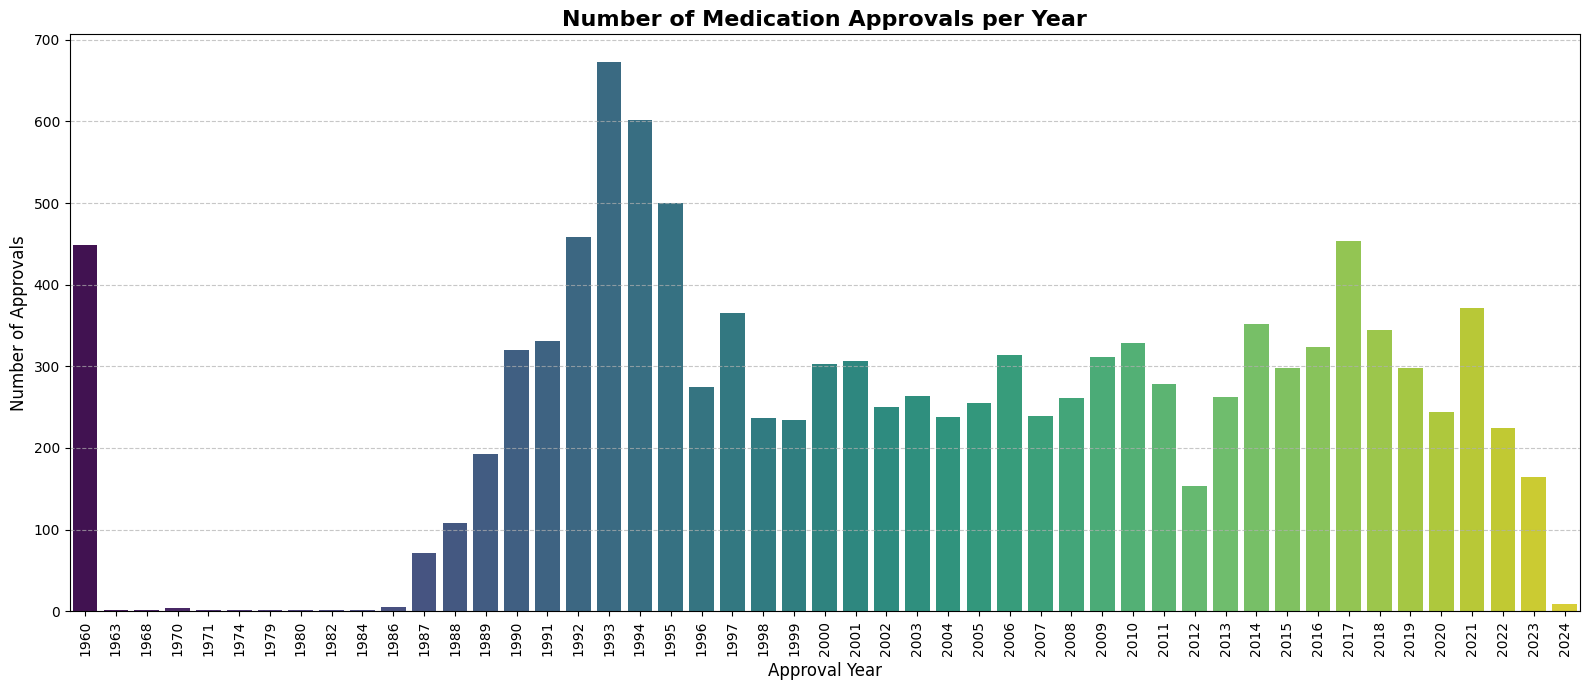

✓ Bar chart showing approval year distribution displayed.


In [ ]:
print("\n--- VISUALIZING APPROVAL YEAR DISTRIBUTION ---")

plt.figure(figsize=(16, 7))
sns.barplot(x=approvals_per_year.index, y=approvals_per_year.values, palette='viridis')
plt.title('Number of Medication Approvals per Year', fontsize=16, fontweight='bold')
plt.xlabel('Approval Year', fontsize=12)
plt.ylabel('Number of Approvals', fontsize=12)
plt.xticks(rotation=90, fontsize=10) # Rotate x-axis labels for better readability
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

print("✓ Bar chart showing approval year distribution displayed.")

**Consolidating All Missing Value Handling**

In [ ]:
print("\n--- CONSOLIDATING ALL MISSING VALUE HANDLING ---")

# Impute categorical columns with 'Unknown'
categorical_cols_to_impute = [
    'Dosage', 'Présentation', 'Sous_Classe', 'Conditionnement_Primaire',
    'Spec_Conditionnement', 'Tableau', 'VEIC', 'Lab_Pays', 'Lab_Adresse',
    'Lab_Tel', 'Fiche_Link', 'Source_Excel', 'Classe', 'Indications', 'dosage_unit', 'dosage_unit_original'
]

for col in categorical_cols_to_impute:
    if col in df_clean.columns and df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna('Unknown')
        print(f"✓ Filled missing values in categorical column '{col}' with 'Unknown'.")

# Impute numerical columns with their median
numerical_cols_to_impute = [
    'Duree_Conservation', 'dosage_value'
]

for col in numerical_cols_to_impute:
    if col in df_clean.columns and df_clean[col].isnull().any():
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"✓ Filled missing values in numerical column '{col}' with median ({median_val:.2f}).")

# Drop 'Lab_Fax' column due to high missing percentage
if 'Lab_Fax' in df_clean.columns:
    df_clean.drop(columns=['Lab_Fax'], inplace=True)
    print("✓ 'Lab_Fax' column dropped due to high missing values.")

print("\n--- Verifying all missing values after consolidated handling ---")
missing_values_final = df_clean.isnull().sum()
print(missing_values_final[missing_values_final > 0])

if missing_values_final.sum() == 0:
    print("\n✓ All missing values have been successfully handled in the DataFrame.")
else:
    print("\n✗ There are still missing values in the DataFrame. Review the columns listed above.")


--- CONSOLIDATING ALL MISSING VALUE HANDLING ---
✓ Filled missing values in categorical column 'Dosage' with 'Unknown'.
✓ Filled missing values in categorical column 'Présentation' with 'Unknown'.
✓ Filled missing values in categorical column 'Sous_Classe' with 'Unknown'.
✓ Filled missing values in categorical column 'Conditionnement_Primaire' with 'Unknown'.
✓ Filled missing values in categorical column 'Spec_Conditionnement' with 'Unknown'.
✓ Filled missing values in categorical column 'Tableau' with 'Unknown'.
✓ Filled missing values in categorical column 'VEIC' with 'Unknown'.
✓ Filled missing values in categorical column 'Lab_Pays' with 'Unknown'.
✓ Filled missing values in categorical column 'Lab_Adresse' with 'Unknown'.
✓ Filled missing values in categorical column 'Lab_Tel' with 'Unknown'.
✓ Filled missing values in categorical column 'Fiche_Link' with 'Unknown'.
✓ Filled missing values in categorical column 'Source_Excel' with 'Unknown'.
✓ Filled missing values in categorical

In [ ]:
print("\n--- Verifying all missing values in the DataFrame ---")
missing_values_final = df_clean.isnull().sum()
print(missing_values_final[missing_values_final > 0])

if missing_values_final.sum() == 0:
    print("\n✓ All missing values have been successfully handled in the DataFrame.")
else:
    print("\n✗ There are still missing values in the DataFrame. Review the columns listed above.")


--- Verifying all missing values in the DataFrame ---
Series([], dtype: int64)

✓ All missing values have been successfully handled in the DataFrame.


In [ ]:
df_clean.shape

(11685, 30)

**Feature Engineering**

In [ ]:
current_year = datetime.now().year
# FEATURE 1: Product age
# WHY: Newer products need more intensive training; very old products may be obsolete
df_clean['product_age_years'] = current_year - df_clean['Date_AMM'].dt.year


# FEATURE 3: Complexity score (composite)
# WHY: Combine multiple factors into single training difficulty metric
df_clean['complexity_score'] = 0

# +2 points for combination products (multiple strengths or ingredients)
combo_mask = df_clean['Dosage'].str.contains(r'[+/]', na=False, regex=True)
df_clean.loc[combo_mask, 'complexity_score'] += 2

# +3 points for injectable forms (higher safety risk, more complex administration)
injectable_mask = df_clean['Forme'].str.contains(
    'injectable|perfusion|intraveineuse', case=False, na=False
)
df_clean.loc[injectable_mask, 'complexity_score'] += 3

# +1 point for drugs with long indication lists
# This feature depended on 'indication_length', so it's also adjusted
# long_ind_mask = df_clean['indication_length'] > 200
# df_clean.loc[long_ind_mask, 'complexity_score'] += 1

# FEATURE 4: High-risk flag
# WHY: Oncology, cardiovascular, and hematology drugs have higher safety stakes
high_risk_classes = [
    'ANTINEOPLASIQUES ET IMMUNOMODULATEURS',  # Chemotherapy
    'SANG ET ORGANES HEMATOPOIETIQUES',       # Blood products, anticoagulants
    'SYSTEME CARDIOVASCULAIRE'                 # Heart drugs (narrow therapeutic index)
]
df_clean['high_risk_flag'] = df_clean['Classe'].isin(high_risk_classes)


# Summary
print("✓ Created features:")
print(f"  1. product_age_years: mean = {df_clean['product_age_years'].mean():.1f} years")
# print(f"  2. indication_length: mean = {df_clean['indication_length'].mean():.1f} characters")
print(f"  2. complexity_score: mean = {df_clean['complexity_score'].mean():.1f}")
print(f"  3. high_risk_flag: {df_clean['high_risk_flag'].sum() / len(df_clean) * 100:.1f}% are high risk")
# print(f"  5. training_priority: mean = {df_clean['training_priority'].mean():.1f}")

print("\n--- Sample with new features ---")
display(df_clean[[
    'Nom', 'Date_AMM', 'product_age_years',
    'Dosage', 'Forme', 'complexity_score',
    'Classe', 'high_risk_flag'
]].head())

✓ Created features:
  1. product_age_years: mean = 23.1 years
  2. complexity_score: mean = 1.1
  3. high_risk_flag: 15.6% are high risk

--- Sample with new features ---


,Nom,Date_AMM,product_age_years,Dosage,Forme,complexity_score,Classe,high_risk_flag
0,5-Fluorouracil,2001-01-20,25,250 MG,Solution injectable,3,ANTINEOPLASIQUES ET IMMUNOMODULATEURS,True
1,5-Fluorouracile Ebewe,2012-04-30,14,1000 mg/20 ml,Solution injectable pour perfusion,5,ANTINEOPLASIQUES ET IMMUNOMODULATEURS,True
2,5-Fluorouracile Ebewe,2012-04-30,14,500 mg/10 ml,Solution injectable pour perfusion,5,ANTINEOPLASIQUES ET IMMUNOMODULATEURS,True
3,Abboticine,1990-12-19,36,200 MG,Poudre pour suspension orale,0,ANTIINFECTIEUX GENERAUX A USAGE SYSTEMIQUE,False
4,Abevmy,2021-09-06,5,400 mg(25mg/ml),Solution à diluer pour perfusion,5,ANTINEOPLASIQUES ET IMMUNOMODULATEURS,True


**Visualize the distributions of the newly created features**




--- VISUALIZING DISTRIBUTION OF REMAINING NEW FEATURES ---


/tmp/ipython-input-2369827923.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_clean['complexity_score'], ax=axes[1], palette='Greens', legend=False)
/tmp/ipython-input-2369827923.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_clean['high_risk_flag'], ax=axes[2], palette='Oranges', legend=False)
/tmp/ipython-input-2369827923.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['Not High-Risk', 'High-Risk'])


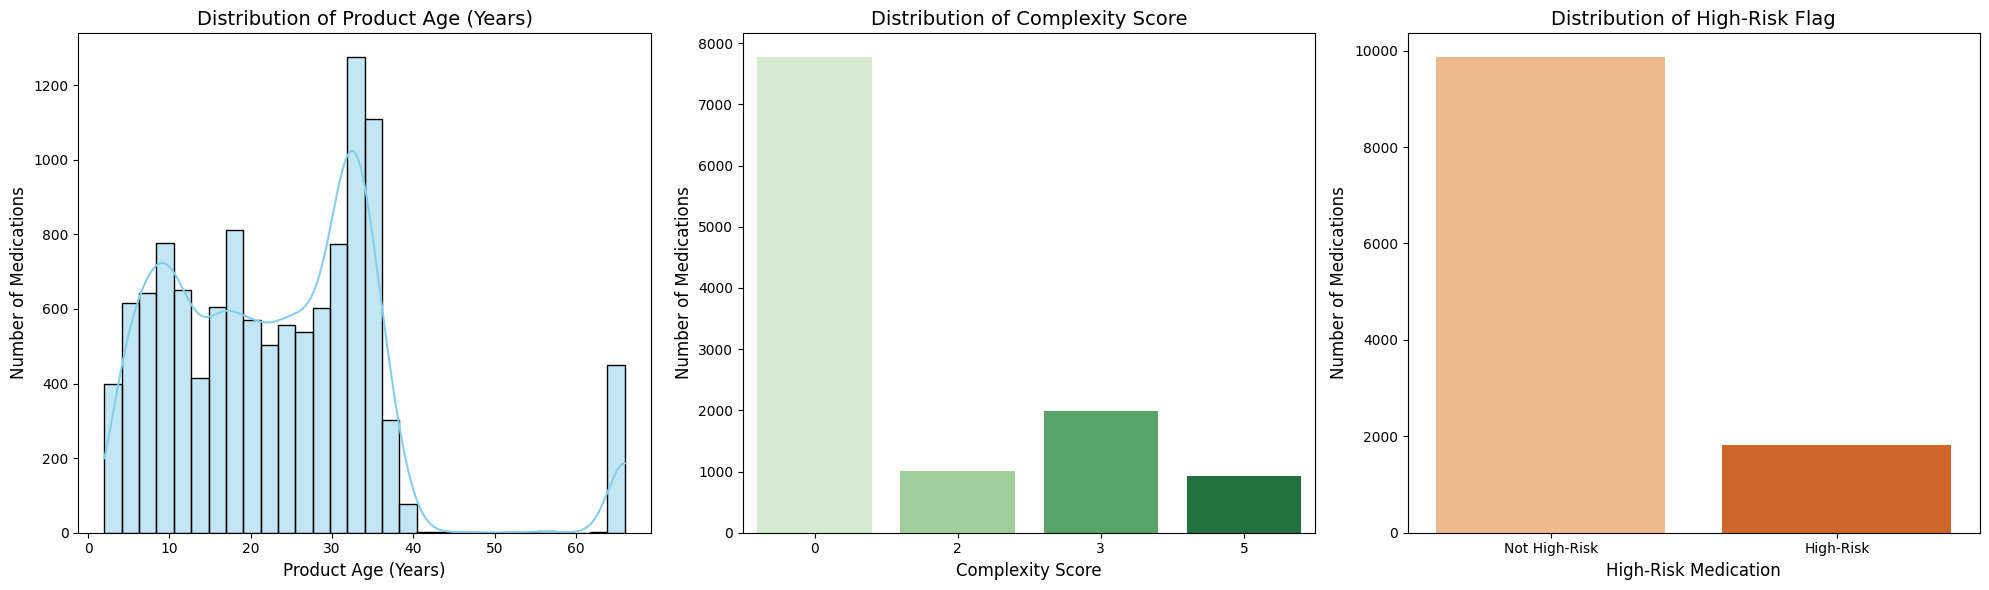

✓ Distributions of remaining new features visualized.


In [ ]:
print("\n--- VISUALIZING DISTRIBUTION OF REMAINING NEW FEATURES ---")

fig, axes = plt.subplots(1, 3, figsize=(20, 6)) # Adjusted for 3 plots
axes = axes.flatten() # Flatten the array of axes for easier iteration

# Plotting 'product_age_years' (continuous - histogram)
sns.histplot(df_clean['product_age_years'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Product Age (Years)', fontsize=14)
axes[0].set_xlabel('Product Age (Years)', fontsize=12)
axes[0].set_ylabel('Number of Medications', fontsize=12)

# Plotting 'complexity_score' (discrete - bar chart)
sns.countplot(x=df_clean['complexity_score'], ax=axes[1], palette='Greens', legend=False)
axes[1].set_title('Distribution of Complexity Score', fontsize=14)
axes[1].set_xlabel('Complexity Score', fontsize=12)
axes[1].set_ylabel('Number of Medications', fontsize=12)

# Plotting 'high_risk_flag' (discrete - bar chart)
sns.countplot(x=df_clean['high_risk_flag'], ax=axes[2], palette='Oranges', legend=False)
axes[2].set_title('Distribution of High-Risk Flag', fontsize=14)
axes[2].set_xlabel('High-Risk Medication', fontsize=12)
axes[2].set_ylabel('Number of Medications', fontsize=12)
axes[2].set_xticklabels(['Not High-Risk', 'High-Risk'])

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

print("✓ Distributions of remaining new features visualized.")

**Visualize the relationship between 'high_risk_flag' and 'complexity_score', as well as 'high_risk_flag' and 'training_priority'**


--- EXPLORING HIGH-RISK FLAG RELATIONSHIPS ---


/tmp/ipython-input-1003250091.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='high_risk_flag', y='complexity_score', data=df_clean, ax=axes, palette='viridis')
/tmp/ipython-input-1003250091.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(['Not High-Risk', 'High-Risk'])


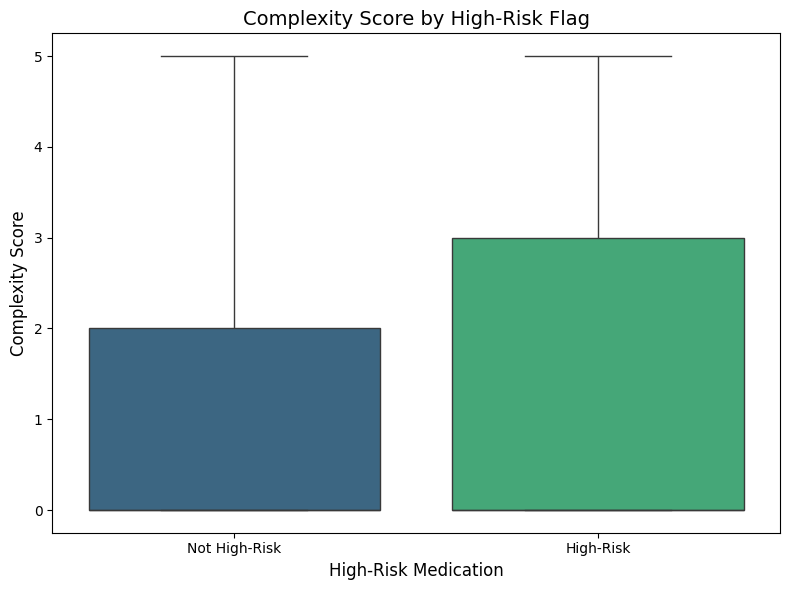

✓ Box plot showing relationship with 'high_risk_flag' displayed.


In [ ]:
print("\n--- EXPLORING HIGH-RISK FLAG RELATIONSHIPS ---")

fig, axes = plt.subplots(1, 1, figsize=(8, 6)) # Create a figure with 1 row and 1 column, as only one plot remains

# Box plot for complexity_score vs high_risk_flag
sns.boxplot(x='high_risk_flag', y='complexity_score', data=df_clean, ax=axes, palette='viridis')
axes.set_title('Complexity Score by High-Risk Flag', fontsize=14)
axes.set_xlabel('High-Risk Medication', fontsize=12)
axes.set_ylabel('Complexity Score', fontsize=12)
axes.set_xticklabels(['Not High-Risk', 'High-Risk'])

# The code for 'training_priority' has been removed as the feature no longer exists.

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

print("✓ Box plot showing relationship with 'high_risk_flag' displayed.")

**visualize the correlations between the specified numerical features**




--- COMPUTING AND VISUALIZING CORRELATION MATRIX ---


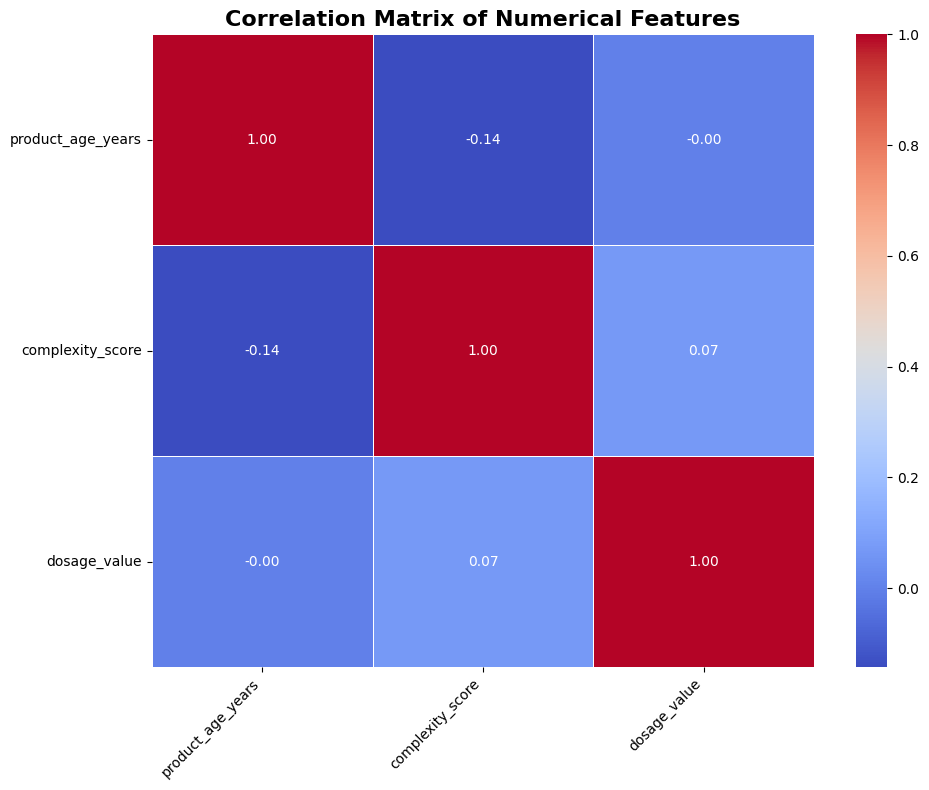


✓ Correlation matrix heatmap displayed.


In [ ]:
print("\n--- COMPUTING AND VISUALIZING CORRELATION MATRIX ---")

# Select the relevant numerical columns for correlation analysis
correlation_features = [
    'product_age_years',
    'complexity_score',
    'dosage_value',
]

# Calculate the Pearson correlation matrix
correlation_matrix = df_clean[correlation_features].corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True, # Show the correlation values on the heatmap
    cmap='coolwarm', # Color map to highlight positive and negative correlations
    fmt=".2f", # Format annotation values to two decimal places
    linewidths=.5 # Add lines between cells
)
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.yticks(rotation=0) # Ensure y-axis labels are horizontal
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

print("\n✓ Correlation matrix heatmap displayed.")

**Visualize the distribution of the top N therapeutic classes (`Classe`).**



--- VISUALIZING DISTRIBUTION OF TOP THERAPEUTIC CLASSES ---


/tmp/ipython-input-4164834114.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_classes.index, y=top_classes.values, palette='coolwarm')


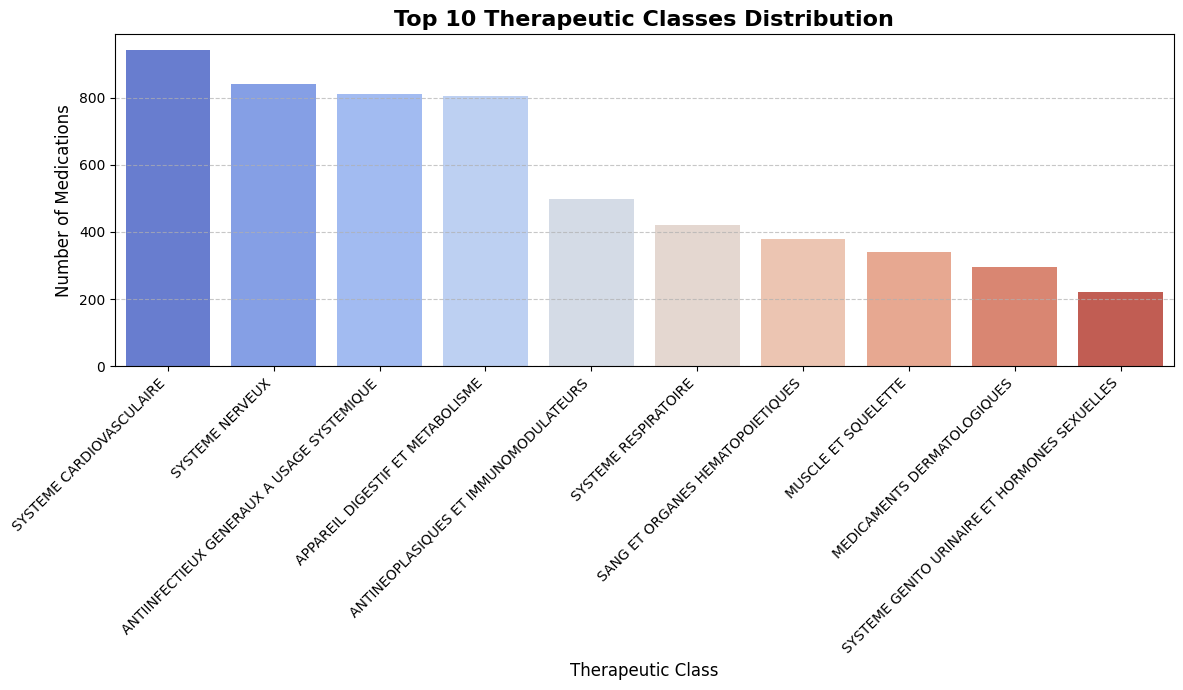


✓ Bar chart showing top 10 therapeutic classes displayed.


In [ ]:
print("\n--- VISUALIZING DISTRIBUTION OF TOP THERAPEUTIC CLASSES ---")

N_top_classes = 10 # Define the number of top classes to visualize

# Get the top N most common classes, excluding 'Unknown' or NaN values if present
top_classes = df_clean['Classe'].value_counts().drop(labels=['Unknown'], errors='ignore').head(N_top_classes)

if not top_classes.empty:
    plt.figure(figsize=(12, 7))
    sns.barplot(x=top_classes.index, y=top_classes.values, palette='coolwarm')
    plt.title(f'Top {N_top_classes} Therapeutic Classes Distribution', fontsize=16, fontweight='bold')
    plt.xlabel('Therapeutic Class', fontsize=12)
    plt.ylabel('Number of Medications', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    print(f"\n✓ Bar chart showing top {N_top_classes} therapeutic classes displayed.")
else:
    print("No therapeutic classes found to plot or all are 'Unknown'.")


**Show the distribution of the top laboratories.**


--- VISUALIZING DISTRIBUTION OF TOP LABORATORIES ---


/tmp/ipython-input-3240863702.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_laboratories.index, y=top_laboratories.values, palette='plasma')


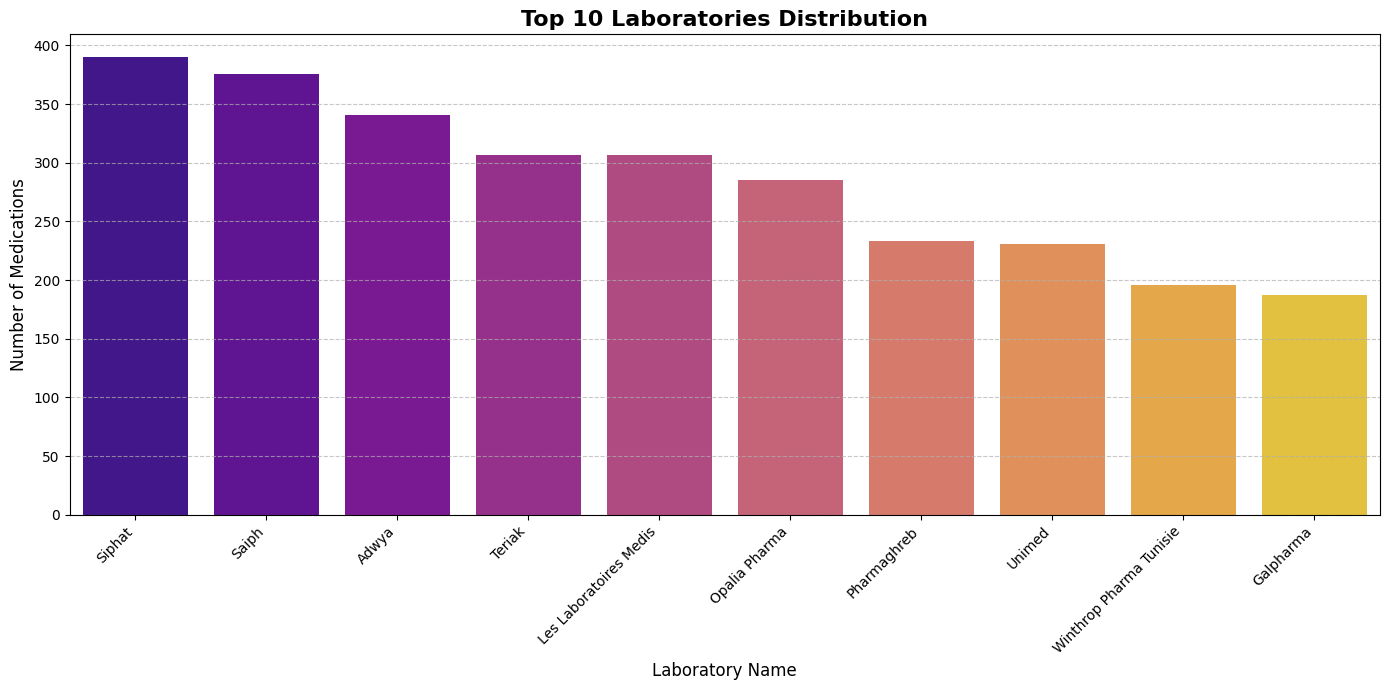


✓ Bar chart showing top 10 laboratories displayed.


In [ ]:
print("\n--- VISUALIZING DISTRIBUTION OF TOP LABORATORIES ---")

N_top_labs = 10 # Define the number of top laboratories to visualize

# Get the top N most common laboratories, excluding 'Unknown' or NaN values if present
top_laboratories = df_clean['Laboratoire'].value_counts().drop(labels=['Unknown'], errors='ignore').head(N_top_labs)

if not top_laboratories.empty:
    plt.figure(figsize=(14, 7))
    sns.barplot(x=top_laboratories.index, y=top_laboratories.values, palette='plasma')
    plt.title(f'Top {N_top_labs} Laboratories Distribution', fontsize=16, fontweight='bold')
    plt.xlabel('Laboratory Name', fontsize=12)
    plt.ylabel('Number of Medications', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    print(f"\n✓ Bar chart showing top {N_top_labs} laboratories displayed.")
else:
    print("No laboratories found to plot or all are 'Unknown'.")

### Outlier Detection for 'product_age_years'

This cell identifies and visualizes outliers in the 'product_age_years' feature using the Interquartile Range (IQR) method.


--- DETECTING OUTLIERS IN 'product_age_years' ---
Number of outliers detected: 450
Lower bound: -18.00, Upper bound: 62.00

--- Sample of Outliers ---


,Nom,Date_AMM,product_age_years
6081,Acnestrol,1960-01-01,66
6105,Acylanide,1960-01-01,66
6117,Adrenaline,1960-01-01,66
6118,Adrenaline,1960-01-01,66
6119,Adrenoxyl,1960-01-01,66


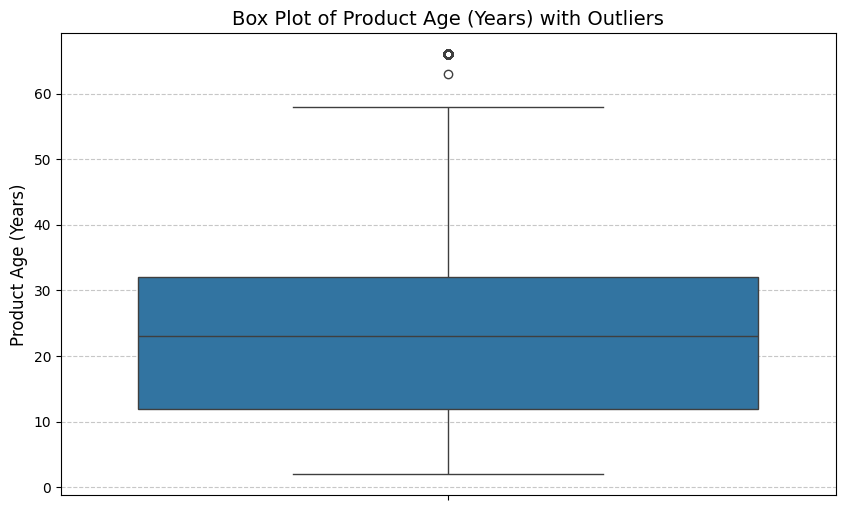

✓ Outliers in 'product_age_years' visualized.


In [ ]:
print("\n--- DETECTING OUTLIERS IN 'product_age_years' ---")

Q1 = df_clean['product_age_years'].quantile(0.25)
Q3 = df_clean['product_age_years'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['product_age_years'] < lower_bound) | (df_clean['product_age_years'] > upper_bound)]

print(f"Number of outliers detected: {len(outliers)}")
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

print("\n--- Sample of Outliers ---")
display(outliers[['Nom', 'Date_AMM', 'product_age_years']].head())

# Visualize outliers using a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_clean['product_age_years'])
plt.title('Box Plot of Product Age (Years) with Outliers', fontsize=14)
plt.ylabel('Product Age (Years)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("✓ Outliers in 'product_age_years' visualized.")